# Halogen generalization error: AIOMFAC coverage ceiling, or feature–label mismatch?

Companion check for paper Sec. 3.3 / notebook Part I §5.

**Why this check is needed.** Every label in the paper is an AIOMFAC output, and every error is
surrogate-vs-AIOMFAC (fidelity) error. AIOMFAC drops unmatched halogen atoms, so the *labels* for a
halogenated molecule are computed for its halogen-free carbon skeleton. A missing halogen subgroup therefore
cannot cap *fidelity* accuracy: the surrogate only has to reproduce what AIOMFAC computes. It caps accuracy
against *real* thermodynamics, which the paper does not measure.

But the *input features* are not computed the way AIOMFAC sees the molecule:

| feature (feature set B) | source | sees halogen? | AIOMFAC label sees halogen? |
|---|---|---|---|
| main-group fractions, log1p(total subgroups) | s2as subgroups | no | no |
| O:C, N:C | RDKit atom counts | no (counts O, N, C only) | no |
| **log(molar mass)** | **RDKit, all atoms** | **yes** | **no**: `aiomfac_py` builds the molar mass from subgroup masses (`system.py`, `SetMolarMass` port), and uses it for the mass-to-mole-fraction conversion |
| N:C, O:C when N/O sit in unmatched groups (amides, N-heterocycles, sulfonyl) | RDKit atom counts | yes | no |

So for 1-iodobutane, the surrogate is told M = 184 g/mol, while AIOMFAC computes the label for a
57 g/mol molecule. The same applies to any other atom that s2as leaves unmatched (S, some N), not only to
halogens. Step 1 tests how common that is.

**Hypotheses and what each predicts**

| | H0: coverage ceiling (paper's reading) | H1: feature–label mismatch |
|---|---|---|
| Step 1: unmatched atoms | halogen only | halogen, plus possibly S/N in other categories |
| Step 3: AIOMFAC labels, halogenated vs H-substituted twin | nearly identical | nearly identical (both readings agree here) |
| Step 4: features from AIOMFAC molar mass (V1) vs RDKit molar mass (V0) | no change | error drops for molecules with unmatched atoms; no change for fully matched ones |
| Step 4: per-molecule error vs mass-deficit fraction | no correlation | positive under V0, gone under V1 |
| Step 5: error after controlling for feature-space novelty | halogen effect remains | halogen/unmatched effect disappears |

**How to run.** Standalone in Colab (CPU is enough; about 25–40 min with the defaults, or around 10 min with
`FAST = True`). Each step can also be pasted into the main notebook after Part I §5. Every trainer call is
explicitly seeded, which avoids the global-RNG drift noted in Part I's reproducibility note.

## 0) Setup

In [1]:
# Upload bimog_unified.json (Colab only). Skip if it is already in the working directory.
try:
    from google.colab import files
    import os
    if not os.path.exists('bimog_unified.json'):
        print("Select bimog_unified.json to upload...")
        uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure bimog_unified.json is in the current directory.")

Not running in Colab -- make sure bimog_unified.json is in the current directory.


In [2]:
# Install aiomfac_py (+ s2as) and RDKit only if they are missing (same install path as Part I).
try:
    import aiomfac_py, rdkit  # noqa: F401
    print("aiomfac_py and rdkit already available")
except ImportError:
    from pathlib import Path
    import subprocess
    REPO_URL = "https://github.com/SeoulTechPSE/aiomfac-python.git"
    REPO_DIR = Path("/content") / "aiomfac-python"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate --smiles")
    subprocess.run(["pip", "install", "-q", "rdkit"], check=True)

aiomfac_py and rdkit already available


In [3]:
import json, time, hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy import stats
from rdkit import Chem, RDLogger

import aiomfac_py as aiomfac
from aiomfac_py import ActivityModel, Component
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py.params import load_subgroup_params
import aiomfac_py.s2as._mapping as _aiomfac_mapping

_aiomfac_mapping.print = lambda *args, **kwargs: None   # silence s2as per-molecule mismatch prints (as Part I)
RDLogger.DisableLog("rdApp.*")

sg = load_subgroup_params()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HALOGENS = {"F", "Cl", "Br", "I"}

# ---- run configuration ----
FAST = False                      # True: 1 seed, for a quick first look
K_FOLDS = 5                       # grouped (molecule-level) cross-validation folds
SEEDS = (0,) if FAST else (0, 1, 2)
print(f"aiomfac_py {aiomfac.__version__} | torch {torch.__version__} | device={DEVICE} | "
      f"K={K_FOLDS} folds x {len(SEEDS)} seeds")

aiomfac_py 0.0.24 | torch 2.14.1 | device=cpu | K=5 folds x 3 seeds


## 1) Diagnostic: which molecules does AIOMFAC see only partially?

Same decomposition as Part I's `decompose_pool`, which keeps every molecule that s2as returns. The
`n_unmatched_atoms` count that s2as reports is never used to flag or exclude molecules, although the Part I
housekeeping cell says it is. This version records it, together with the molar mass AIOMFAC actually uses.

In [4]:
def bimog_category(d):
    has_n, has_hal = d["#N"] != 0, d["#Hal"] != 0
    if has_n and has_hal:
        return "bimog_n_and_hal"
    if has_n:
        return "bimog_n_only"
    if has_hal:
        return "bimog_hal_only"
    return "cho"


def decompose_pool_v(candidates):
    '''Part I decompose_pool + coverage diagnostics (unmatched atoms, AIOMFAC-internal molar mass).'''
    kept, removed = [], []
    for d in candidates:
        smi = d["smiles"]
        r = smiles_to_components([smi], water_as_component1=True)
        if r.removed:
            removed.append((d["name"], smi, r.removed[0][2]))
            continue
        organic = r.components[1]
        try:
            m = ActivityModel(r.components)
            res = m.evaluate([0.9, 0.1], 298.15, basis="mass")
            if not (res.gamma_neutral > 0).all():
                raise ValueError("non-positive gamma at sanity point")
        except Exception as exc:
            removed.append((d["name"], smi, f"ActivityModel failed: {exc}"))
            continue
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            removed.append((d["name"], smi, "RDKit could not parse"))
            continue
        mol_h = Chem.AddHs(mol)
        sym = [a.GetSymbol() for a in mol_h.GetAtoms()]
        n_c, n_o, n_n = sym.count("C"), sym.count("O"), sym.count("N")
        mw = sum(a.GetMass() for a in mol_h.GetAtoms())
        mw_aiomfac = float(m.mixture.mmass[1]) * 1.0e3          # kg/mol -> g/mol, sum of subgroup masses
        kept.append({"name": d["name"], "smiles": smi, "category": d.get("category", "cho"),
                     "subgroups": organic.subgroups, "molar_mass_g_mol": mw,
                     "o_to_c": n_o / max(n_c, 1), "n_to_c": n_n / max(n_c, 1),
                     # --- new diagnostics ---
                     "mw_aiomfac_g_mol": mw_aiomfac,
                     "mass_deficit_frac": 1.0 - mw_aiomfac / mw,
                     "n_unmatched": int(r.n_unmatched_atoms[0]),
                     "n_heavy": mol.GetNumHeavyAtoms(),
                     "n_hal": sum(s in HALOGENS for s in sym),
                     "n_S": sym.count("S"), "n_N": n_n})
    return kept, removed


with open("bimog_unified.json") as f:
    bimog = json.load(f)
cands = [{"smiles": d["smiles"], "name": d["name"], "category": bimog_category(d)} for d in bimog]
pool, removed = decompose_pool_v(cands)
print(f"kept {len(pool)} / {len(cands)} ({len(removed)} removed)")

diag = pd.DataFrame([{k: o[k] for k in ("name", "smiles", "category", "molar_mass_g_mol", "mw_aiomfac_g_mol",
                                        "mass_deficit_frac", "n_unmatched", "n_heavy", "n_hal", "n_S", "n_N")}
                     for o in pool])
diag["has_unmatched"] = diag["n_unmatched"] > 0
diag["unmatched_non_hal"] = (diag["n_unmatched"] - diag["n_hal"]).clip(lower=0)

summary = diag.groupby("category").agg(
    n_mol=("name", "size"),
    frac_with_unmatched=("has_unmatched", "mean"),
    median_mass_deficit=("mass_deficit_frac", "median"),
    max_mass_deficit=("mass_deficit_frac", "max"),
    mols_with_unmatched_non_hal=("unmatched_non_hal", lambda s: int((s > 0).sum())))
display(summary.round(3))
print("\nLargest mass deficits (fraction of the real molar mass AIOMFAC does not see):")
display(diag.sort_values("mass_deficit_frac", ascending=False)
            [["name", "category", "molar_mass_g_mol", "mw_aiomfac_g_mol", "mass_deficit_frac",
              "n_unmatched", "n_hal", "n_S", "n_N"]].head(15).round(3))

kept 368 / 368 (0 removed)


,n_mol,frac_with_unmatched,median_mass_deficit,max_mass_deficit,mols_with_unmatched_non_hal
category,,,,,
bimog_hal_only,22,1.000,0.349,0.810,0
bimog_n_and_hal,29,1.000,0.254,0.537,28
bimog_n_only,74,0.932,0.093,0.326,68
cho,243,0.012,0.000,0.124,3



Largest mass deficits (fraction of the real molar mass AIOMFAC does not see):


,name,category,molar_mass_g_mol,mw_aiomfac_g_mol,mass_deficit_frac,n_unmatched,n_hal,n_S,n_N
277,trichloroethylene,bimog_hal_only,131.389,25.028,0.810,3,3,0,0
273,1-iodobutane,bimog_hal_only,184.020,57.112,0.690,1,1,0,0
272,1 -bromopropane,bimog_hal_only,122.993,43.086,0.650,1,1,0,0
275,iodobenzene,bimog_hal_only,204.010,77.100,0.622,1,1,0,0
266,isobutylbromide,bimog_hal_only,137.020,57.112,0.583,1,1,0,0
265,1-bromobutane,bimog_hal_only,137.020,57.112,0.583,1,1,0,0
284,"3,4-dichloroaniline",bimog_n_and_hal,162.019,75.084,0.537,3,2,0,1
268,3-bromopentane,bimog_hal_only,151.047,71.138,0.529,1,1,0,0
267,isoamylbromide,bimog_hal_only,151.047,71.138,0.529,1,1,0,0
270,bromobenzene,bimog_hal_only,157.010,77.100,0.509,1,1,0,0


**Read this first.** If `mols_with_unmatched_non_hal > 0` for `bimog_n_only` or `cho`, the mismatch is not
halogen-specific. S, or N in groups AIOMFAC has no subgroup for (amides, N-heterocycles), is dropped the same
way. Sec. 3.3 would then also need to cover the N categories.

In [5]:
# How the dropped mass shifts the composition AIOMFAC actually evaluates (example: worst-deficit molecule).
row = diag.sort_values("mass_deficit_frac", ascending=False).iloc[0]
M_w = 18.015
print(f"{row['name']}: RDKit M = {row.molar_mass_g_mol:.1f} g/mol, AIOMFAC M = {row.mw_aiomfac_g_mol:.1f} g/mol")
print(f"{'w_water':>8s} {'x_water (real M)':>17s} {'x_water (AIOMFAC M)':>20s}")
for w in (0.1, 0.3, 0.5, 0.7, 0.9):
    x_real = (w / M_w) / (w / M_w + (1 - w) / row.molar_mass_g_mol)
    x_aio = (w / M_w) / (w / M_w + (1 - w) / row.mw_aiomfac_g_mol)
    print(f"{w:8.2f} {x_real:17.3f} {x_aio:20.3f}")
print("\nThe surrogate input is w_water + log(RDKit M); the label was computed at the AIOMFAC-M mole fraction.")

trichloroethylene: RDKit M = 131.4 g/mol, AIOMFAC M = 25.0 g/mol
 w_water  x_water (real M)  x_water (AIOMFAC M)
    0.10             0.448                0.134
    0.30             0.758                0.373
    0.50             0.879                0.581
    0.70             0.944                0.764
    0.90             0.985                0.926

The surrogate input is w_water + log(RDKit M); the label was computed at the AIOMFAC-M mole fraction.


## 2) Labels for training (identical across all feature variants)

Same sampling as Part I `build_dataset`: 20 jittered water-mass-fraction points × 4 temperatures per
molecule. Only the **features** change between variants. The labels stay the same, so any difference in
error between variants comes from the features alone.

In [6]:
def build_dataset(kept, seed=0, n_comp=20, n_temp=4):
    '''Part I build_dataset, unchanged.'''
    rng = np.random.RandomState(seed)
    rows = []
    for oi, o in enumerate(kept):
        water = Component(1, "Water", ((16, 1),))
        organic = Component(2, o["name"], tuple((s, q) for s, q in o["subgroups"]))
        try:
            m = ActivityModel([water, organic])
        except Exception:
            continue
        edges = np.linspace(0.02, 0.98, n_comp + 1)
        wtf_water = rng.uniform(edges[:-1], edges[1:])
        temps = rng.uniform(273.15, 313.15, n_temp)
        for wtf_w in wtf_water:
            for T in temps:
                try:
                    res = m.evaluate([wtf_w, 1.0 - wtf_w], T, basis="mass")
                    lw, lo = float(res.ln_gamma[0]), float(res.ln_gamma[1])
                    if np.isfinite(lw) and np.isfinite(lo):
                        rows.append({"organic_idx": oi, "wtf_water": float(wtf_w), "T_K": float(T),
                                     "ln_gamma_water": lw, "ln_gamma_organic": lo})
                except Exception:
                    continue
    return rows


t0 = time.time()
rows = build_dataset(pool)
organic_idx = np.array([r["organic_idx"] for r in rows])
X_comp_T = np.array([[r["wtf_water"], (r["T_K"] - 293.15) / 20.0] for r in rows], dtype=np.float32)
Y = np.array([[r["ln_gamma_water"], r["ln_gamma_organic"]] for r in rows], dtype=np.float32)
print(f"{len(rows)} labeled points from {len(pool)} molecules in {time.time()-t0:.1f}s")

29440 labeled points from 368 molecules in 2.5s


## 3) Twin test: does AIOMFAC distinguish a halogenated molecule from its H-substituted twin?

For each halogen-containing molecule, every halogen is replaced by H. We then compare (i) the AIOMFAC label
curves and (ii) the RDKit molar-mass feature. Both H0 and H1 predict small label differences: the only
difference is that a C–X carbon is counted as CH(n−1) rather than CHn. Only H1 predicts large feature
differences paired with near-equal labels, which is exactly the inconsistency the surrogate is asked to learn.

In [7]:
_HAL_PATT = Chem.MolFromSmarts("[F,Cl,Br,I]")
W_GRID = np.linspace(0.05, 0.95, 19)


def dehalogenate(smi):
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.ReplaceSubstructs(mol, _HAL_PATT, Chem.MolFromSmiles("[H]"), replaceAll=True)[0]
    mol = Chem.RemoveHs(mol)
    Chem.SanitizeMol(mol)
    return Chem.MolToSmiles(mol)


def label_curve(subgroups, T=298.15):
    m = ActivityModel([Component(1, "Water", ((16, 1),)), Component(2, "org", tuple(subgroups))])
    return np.array([m.evaluate([w, 1 - w], T, basis="mass").ln_gamma[:2] for w in W_GRID])


twin_rows = []
for o in pool:
    if o["n_hal"] == 0:
        continue
    try:
        tw_smi = dehalogenate(o["smiles"])
        r = smiles_to_components([tw_smi], water_as_component1=True)
        if r.removed:
            continue
        tw_sub = r.components[1].subgroups
        tw_mw = sum(a.GetMass() for a in Chem.AddHs(Chem.MolFromSmiles(tw_smi)).GetAtoms())
        c_hal, c_twin = label_curve(o["subgroups"]), label_curve(tw_sub)
    except Exception as exc:
        print(f"  skipped {o['name']}: {exc}")
        continue
    twin_rows.append({
        "name": o["name"], "category": o["category"], "twin_smiles": tw_smi,
        "same_subgroups": dict(o["subgroups"]) == dict(tw_sub),
        "max_dlnγ_org_label": float(np.max(np.abs(c_hal[:, 1] - c_twin[:, 1]))),
        "max_dlnγ_w_label": float(np.max(np.abs(c_hal[:, 0] - c_twin[:, 0]))),
        "d_logM_feature_rdkit": float(np.log(o["molar_mass_g_mol"]) - np.log(tw_mw)),
        "d_logM_feature_aiomfac": float(np.log(o["mw_aiomfac_g_mol"])
                                        - np.log(ActivityModel(r.components).mixture.mmass[1] * 1e3)),
    })
twin = pd.DataFrame(twin_rows)
display(twin.drop(columns="twin_smiles").round(3))

# Reference scale: how much lnγ_org typically varies between *different* CHO molecules
cho_curves = [label_curve(o["subgroups"])[:, 1] for o in pool if o["category"] == "cho"][:60]
pair_d = [np.max(np.abs(a - b)) for i, a in enumerate(cho_curves) for b in cho_curves[i + 1:]]
print(f"\nmedian |Δ lnγ_org| halogenated vs. twin : {twin['max_dlnγ_org_label'].median():.3f}")
print(f"median |Δ lnγ_org| between two CHO molecules : {np.median(pair_d):.3f}  (reference scale)")
print(f"median Δ log(M) feature, RDKit             : {twin['d_logM_feature_rdkit'].median():.3f}")
print(f"median Δ log(M) feature, AIOMFAC-consistent : {twin['d_logM_feature_aiomfac'].median():.3f}")

,name,category,same_subgroups,max_dlnγ_org_label,max_dlnγ_w_label,d_logM_feature_rdkit,d_logM_feature_aiomfac
0,1-bromobutane,bimog_hal_only,False,0.257,0.029,0.858,-0.017
1,isobutylbromide,bimog_hal_only,False,0.257,0.029,0.858,-0.017
2,isoamylbromide,bimog_hal_only,False,0.238,0.029,0.739,-0.014
3,3-bromopentane,bimog_hal_only,False,0.237,0.031,0.739,-0.014
4,9-bromophenanthrene,bimog_hal_only,False,0.144,0.074,0.366,-0.006
5,bromobenzene,bimog_hal_only,False,0.079,0.111,0.698,-0.013
6,tert-butyl-chloride,bimog_hal_only,False,0.330,0.028,0.465,-0.017
7,1 -bromopropane,bimog_hal_only,False,0.285,0.024,1.026,-0.023
8,1-iodobutane,bimog_hal_only,False,0.257,0.029,1.152,-0.017
9,isobutylchloride,bimog_hal_only,False,0.257,0.029,0.465,-0.017



median |Δ lnγ_org| halogenated vs. twin : 0.140
median |Δ lnγ_org| between two CHO molecules : 5.575  (reference scale)
median Δ log(M) feature, RDKit             : 0.219
median Δ log(M) feature, AIOMFAC-consistent : -0.010


## 4) Main test: feature-variant ablation with grouped K-fold cross-validation

The paper's single hash split holds out only about 9 halogen-containing molecules, too few to support any
conclusion. Here every molecule is held out exactly once (folds are assigned by `sha256(SMILES) mod K`), and
each fold is trained with several seeds. The architecture and optimizer are the same as Part I
`train_and_eval`: 3×128 ReLU, Adam with lr 1e-3 and wd 1e-5, batch 256, early stopping with patience 30 on a
random 10 % of the training points.

| variant | molar-mass feature | extra features |
|---|---|---|
| **V0** (paper) | RDKit, all atoms | none |
| **V1** (label-consistent) | AIOMFAC (sum of subgroup masses) | none |
| **V2** (flagged) | RDKit | mass-deficit fraction, unmatched-atom fraction |
| **V3** (subgroup-only) | AIOMFAC | none; O:C and N:C dropped, so *every* feature is derived from what AIOMFAC sees |

For fully matched molecules, V0 and V1 have identical features. Any V0/V1 difference there is training
noise, so those molecules act as a built-in control.

In [8]:
MAIN_GROUPS = sorted({sg.main_group(int(s)) for o in pool for s, q in o["subgroups"]})


def rich_features_v(kept, variant):
    '''Part I rich_features (feature set B), with the molar-mass source switchable.'''
    mg_index = {g: i for i, g in enumerate(MAIN_GROUPS)}
    feat = []
    for o in kept:
        mg_counts, total_q = np.zeros(len(MAIN_GROUPS)), 0
        for s, q in o["subgroups"]:
            mg_counts[mg_index[sg.main_group(int(s))]] += q
            total_q += q
        mw = o["mw_aiomfac_g_mol"] if variant in ("V1", "V3") else o["molar_mass_g_mol"]
        if variant == "V3":
            f = [*(mg_counts / max(total_q, 1)), np.log(mw), np.log1p(total_q)]
        else:
            f = [*(mg_counts / max(total_q, 1)), o["o_to_c"], o["n_to_c"], np.log(mw), np.log1p(total_q)]
        if variant == "V2":
            f += [o["mass_deficit_frac"], o["n_unmatched"] / max(o["n_heavy"], 1)]
        feat.append(f)
    return np.array(feat, dtype=np.float32)


class MLPHead(nn.Module):
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


def train_predict(X, Y, train_pts, test_pts, seed, max_epochs=500, patience=30, batch=256):
    '''Seeded re-implementation of Part I train_and_eval's training loop; returns predictions for test_pts.'''
    rng = np.random.RandomState(seed)
    torch.manual_seed(seed)
    tr = train_pts.copy(); rng.shuffle(tr)
    n_val = int(0.1 * len(tr))
    val, fit = tr[:n_val], tr[n_val:]
    x_mean, x_std = X[fit].mean(0), X[fit].std(0) + 1e-6
    y_mean, y_std = Y[fit].mean(0), Y[fit].std(0) + 1e-6
    T = lambda a: torch.tensor(a, dtype=torch.float32, device=DEVICE)
    Xf, Yf = T((X[fit] - x_mean) / x_std), T((Y[fit] - y_mean) / y_std)
    Xv, Yv = T((X[val] - x_mean) / x_std), T((Y[val] - y_mean) / y_std)
    model = MLPHead(X.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    best, best_state, bad = float("inf"), None, 0
    for epoch in range(max_epochs):
        model.train()
        perm = torch.from_numpy(rng.permutation(len(fit))).to(DEVICE)
        for s in range(0, len(fit), batch):
            idx = perm[s:s + batch]
            opt.zero_grad()
            loss_fn(model(Xf[idx]), Yf[idx]).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xv), Yv).item()
        if v < best - 1e-5:
            best, best_state, bad = v, {k: t.clone() for k, t in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    with torch.no_grad():
        pred = model(T((X[test_pts] - x_mean) / x_std)).cpu().numpy() * y_std + y_mean
    return pred


def sha_mod(smiles, k):
    return int(hashlib.sha256(smiles.encode()).hexdigest(), 16) % k


fold_of_mol = np.array([sha_mod(o["smiles"], K_FOLDS) for o in pool])
fold_of_pt = fold_of_mol[organic_idx]
print("molecules per fold:", np.bincount(fold_of_mol))

molecules per fold: [96 67 73 73 59]


In [9]:
VARIANTS = ("V0", "V1", "V2", "V3")
oof = []          # one row per (variant, seed, molecule)
t0 = time.time()
for variant in VARIANTS:
    feat = rich_features_v(pool, variant)
    X = np.concatenate([feat[organic_idx], X_comp_T], axis=1)
    for seed in SEEDS:
        for k in range(K_FOLDS):
            train_pts, test_pts = np.where(fold_of_pt != k)[0], np.where(fold_of_pt == k)[0]
            pred = train_predict(X, Y, train_pts, test_pts, seed=1000 * seed + k)
            err = np.abs(pred - Y[test_pts])
            for oi in np.unique(organic_idx[test_pts]):
                sel = organic_idx[test_pts] == oi
                oof.append({"variant": variant, "seed": seed, "mol": int(oi),
                            "mae_w": float(err[sel, 0].mean()), "mae_org": float(err[sel, 1].mean())})
        print(f"  {variant} seed {seed} done  ({time.time()-t0:.0f}s elapsed)")
oof = pd.DataFrame(oof).merge(diag.reset_index().rename(columns={"index": "mol"}), on="mol")
oof.to_csv("halogen_mismatch_oof.csv", index=False)
print("saved per-molecule out-of-fold errors -> halogen_mismatch_oof.csv")

  V0 seed 0 done  (57s elapsed)


  V0 seed 1 done  (105s elapsed)


  V0 seed 2 done  (153s elapsed)


  V1 seed 0 done  (196s elapsed)


  V1 seed 1 done  (238s elapsed)


...

  V2 seed 1 done  (379s elapsed)


  V2 seed 2 done  (439s elapsed)


  V3 seed 0 done  (489s elapsed)


  V3 seed 1 done  (525s elapsed)


  V3 seed 2 done  (573s elapsed)
saved per-molecule out-of-fold errors -> halogen_mismatch_oof.csv


In [10]:
# ---- 4a. category-level summary (mean over molecules, then mean ± sd over seeds) ----
oof["group"] = np.where(oof["has_unmatched"], "has unmatched atoms", "fully matched")
def seed_table(by):
    t = (oof.groupby(["variant", "seed", by])["mae_org"].mean()
             .groupby(["variant", by]).agg(["mean", "std"]).round(3))
    return t["mean"].astype(str) + " ± " + t["std"].fillna(0).astype(str)
print("Out-of-fold MAE, ln γ_organic, by BIMOG category")
display(seed_table("category").unstack("variant"))
print("Out-of-fold MAE, ln γ_organic, by coverage group")
display(seed_table("group").unstack("variant"))

# ---- 4b. paired per-molecule tests (seed-averaged), V1 vs V0 and V2 vs V0 ----
per_mol = oof.groupby(["variant", "mol"])["mae_org"].mean().unstack("variant")
per_mol = per_mol.join(diag[["category", "has_unmatched", "mass_deficit_frac"]])
for alt in ("V1", "V2", "V3"):
    for grp, sub in per_mol.groupby("has_unmatched"):
        d = sub[alt] - sub["V0"]
        p = stats.wilcoxon(sub[alt], sub["V0"]).pvalue if len(sub) > 5 else float("nan")
        print(f"{alt} - V0 | {'has unmatched' if grp else 'fully matched':14s} n={len(sub):3d} "
              f"median Δ={d.median():+.3f}  mean Δ={d.mean():+.3f}  "
              f"rel. change of mean={100*d.mean()/sub['V0'].mean():+.0f}%  Wilcoxon p={p:.2g}")

# ---- 4c. does error scale with how much mass AIOMFAC drops? ----
for v in VARIANTS:
    rho, p = stats.spearmanr(per_mol["mass_deficit_frac"], per_mol[v])
    print(f"Spearman(mass deficit, per-molecule error) {v}: rho={rho:+.2f}  p={p:.2g}")

Out-of-fold MAE, ln γ_organic, by BIMOG category


variant,V0,V1,V2,V3
category,,,,
bimog_hal_only,0.266 ± 0.073,0.195 ± 0.041,0.325 ± 0.009,0.22 ± 0.056
bimog_n_and_hal,0.316 ± 0.062,0.328 ± 0.062,0.385 ± 0.06,0.28 ± 0.026
bimog_n_only,0.522 ± 0.011,0.521 ± 0.035,0.539 ± 0.02,0.507 ± 0.055
cho,0.231 ± 0.004,0.235 ± 0.008,0.237 ± 0.014,0.236 ± 0.006


Out-of-fold MAE, ln γ_organic, by coverage group


variant,V0,V1,V2,V3
group,,,,
fully matched,0.246 ± 0.006,0.248 ± 0.008,0.252 ± 0.019,0.248 ± 0.006
has unmatched atoms,0.402 ± 0.008,0.396 ± 0.022,0.439 ± 0.013,0.383 ± 0.036


V1 - V0 | fully matched  n=245 median Δ=-0.000  mean Δ=+0.001  rel. change of mean=+0%  Wilcoxon p=0.62
V1 - V0 | has unmatched  n=123 median Δ=-0.003  mean Δ=-0.005  rel. change of mean=-1%  Wilcoxon p=0.81
V2 - V0 | fully matched  n=245 median Δ=+0.003  mean Δ=+0.006  rel. change of mean=+2%  Wilcoxon p=0.31
V2 - V0 | has unmatched  n=123 median Δ=+0.011  mean Δ=+0.037  rel. change of mean=+9%  Wilcoxon p=0.032
V3 - V0 | fully matched  n=245 median Δ=+0.001  mean Δ=+0.002  rel. change of mean=+1%  Wilcoxon p=0.22
V3 - V0 | has unmatched  n=123 median Δ=-0.012  mean Δ=-0.019  rel. change of mean=-5%  Wilcoxon p=0.22
Spearman(mass deficit, per-molecule error) V0: rho=+0.29  p=1e-08
Spearman(mass deficit, per-molecule error) V1: rho=+0.29  p=1.2e-08
Spearman(mass deficit, per-molecule error) V2: rho=+0.32  p=2.3e-10
Spearman(mass deficit, per-molecule error) V3: rho=+0.25  p=8.6e-07


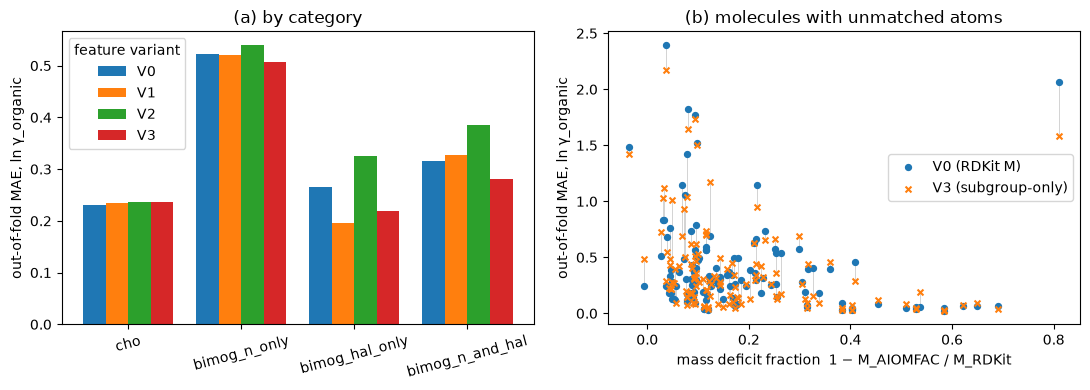

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cats = ["cho", "bimog_n_only", "bimog_hal_only", "bimog_n_and_hal"]
w = 0.2
for j, v in enumerate(VARIANTS):
    m = [per_mol.loc[per_mol.category == c, v].mean() for c in cats]
    axes[0].bar(np.arange(len(cats)) + (j - 1.5) * w, m, w, label=v)
axes[0].set_xticks(range(len(cats)), cats, rotation=15)
axes[0].set_ylabel("out-of-fold MAE, ln γ_organic")
axes[0].legend(title="feature variant")
axes[0].set_title("(a) by category")
um = per_mol[per_mol.has_unmatched]
axes[1].scatter(um["mass_deficit_frac"], um["V0"], s=18, label="V0 (RDKit M)")
axes[1].scatter(um["mass_deficit_frac"], um["V3"], s=18, marker="x", label="V3 (subgroup-only)")
for _, r in um.iterrows():
    axes[1].plot([r.mass_deficit_frac] * 2, [r.V0, r.V3], color="0.8", lw=0.6, zorder=0)
axes[1].set_xlabel("mass deficit fraction  1 − M_AIOMFAC / M_RDKit")
axes[1].set_ylabel("out-of-fold MAE, ln γ_organic")
axes[1].legend()
axes[1].set_title("(b) molecules with unmatched atoms")
plt.tight_layout()
plt.savefig("halogen_mismatch_check.png", dpi=200)
plt.show()

## 5) Control for feature-space novelty

Halogenated BIMOG compounds are often also unusual in other ways (aromatic, pharmaceutical-like). Their
error could therefore come from ordinary distribution shift rather than anything halogen-specific. To test
this, we regress per-molecule error on (i) the distance to the nearest *training-fold* molecule in
standardized V3 feature space, (ii) the molecule's label magnitude (mean |ln γ_org|; larger targets give
larger absolute errors), and (iii) a has-unmatched-atoms indicator, with bootstrap CIs. Under H1, the
indicator's coefficient should be clearly positive under V0 and shrink toward 0 under V1/V3.

In [12]:
F1 = rich_features_v(pool, "V3")
F1s = (F1 - F1.mean(0)) / (F1.std(0) + 1e-6)
nn_dist = np.empty(len(pool))
for i in range(len(pool)):
    other = fold_of_mol != fold_of_mol[i]
    nn_dist[i] = np.min(np.linalg.norm(F1s[other] - F1s[i], axis=1))
per_mol["nn_dist"] = nn_dist[per_mol.index]
per_mol["label_mag"] = pd.Series(np.abs(Y[:, 1])).groupby(organic_idx).mean().reindex(per_mol.index).values

def ols_boot(y, X, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    A = np.column_stack([np.ones(len(y)), X])
    beta = np.linalg.lstsq(A, y, rcond=None)[0]
    boots = []
    for _ in range(n_boot):
        i = rng.randint(0, len(y), len(y))
        boots.append(np.linalg.lstsq(A[i], y[i], rcond=None)[0])
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
    return beta, lo, hi

Xreg = np.column_stack([per_mol["nn_dist"].values, per_mol["label_mag"].values,
                        per_mol["has_unmatched"].astype(float).values])
for v in VARIANTS:
    b, lo, hi = ols_boot(per_mol[v].values, Xreg)
    print(f"{v}: error = {b[0]:.3f} + {b[1]:.3f}·nn_dist [{lo[1]:.3f},{hi[1]:.3f}] "
          f"+ {b[2]:.3f}·label_mag [{lo[2]:.3f},{hi[2]:.3f}] "
          f"+ {b[3]:+.3f}·has_unmatched [{lo[3]:+.3f},{hi[3]:+.3f}]")

V0: error = 0.001 + 0.091·nn_dist [0.056,0.180] + 0.041·label_mag [0.025,0.060] + +0.086·has_unmatched [-0.005,+0.173]
V1: error = 0.001 + 0.087·nn_dist [0.052,0.165] + 0.043·label_mag [0.025,0.062] + +0.078·has_unmatched [-0.017,+0.172]
V2: error = -0.030 + 0.097·nn_dist [0.061,0.180] + 0.050·label_mag [0.029,0.071] + +0.104·has_unmatched [+0.012,+0.192]
V3: error = 0.007 + 0.089·nn_dist [0.050,0.168] + 0.041·label_mag [0.025,0.057] + +0.067·has_unmatched [-0.019,+0.149]


## 6) How to read the outcome (and what to change in the paper)

| outcome | conclusion | change to Sec. 3.3 / Discussion |
|---|---|---|
| V1/V3 ≪ V0 for molecules with unmatched atoms, no change for fully matched ones, `has_unmatched` coefficient → 0 under V1/V3 | **H1 supported.** The elevated error was an inconsistency between features and labels, not an AIOMFAC ceiling. | Replace the "ceiling" claim. State that the labels ignore unmatched atoms, so features must be computed the same way (AIOMFAC molar mass, or subgroup-only features as in V3). Report the V1/V3 numbers in Table 1. Keep the coverage gap as a separate statement about accuracy against real thermodynamics, not fidelity. |
| V2 ≈ V1 < V0 | The model can correct for the mismatch once it is told about it. | Same as above. V1 is the cleaner fix; mention V2 only in passing. |
| No V0/V1/V3 difference, but `has_unmatched` coefficient stays > 0 after the nn_dist control | The mass mismatch is not the channel, yet something about these molecules is still harder. | Look at other channels (e.g. AIOMFAC sees a fragment whose group composition is atypical, or CH2/CH3 split artifacts at C–X carbons). In either case this is a property of how AIOMFAC represents these molecules, not a fidelity ceiling. |
| No difference, and the effect disappears after the nn_dist control | Ordinary distribution shift: these molecules are simply far from the training set. | Reframe as feature-space novelty, consistent with the malonic-acid discussion in Sec. 3.11. |

Separately from the outcome: molecules with `n_unmatched > 0` are, by construction, modeled by AIOMFAC as a
different molecule. The cleanest paper-level choice is often to **exclude them from the pool** (or report
them separately) and say so in Sec. 2.1, especially if Step 1 shows unmatched S/N atoms outside the halogen
categories.